# 🏦 Model Risk Specialist — Business Case Answers
## Compass Feature Pipeline · Solara Digital Bank

> **Role**: Model Risk Specialist (IC5) — ML/AI Data & Infra Risks  
> **System**: Compass — Feature store + batch/streaming pipeline for credit models  

---

## Estrutura

| Seção | Conteúdo |
|---|---|
| **Q1.1** | Risk Landscape — Infrastructure & Data Risks |
| **Q1.2** | Assessment Approach — Tests on the Live System |
| **Q1.3** | Position on Proposed Changes |
| **Q1.4** | Governance Foundations — Key Controls |
| **Q2** | Governance Framework Design for Data Mesh |

---

**Metodologia**: Todas as observações são baseadas em evidências — obtidas rodando o sistema, consultando os SQLite stores e lendo o código-fonte. Cada afirmação é suportada por referência de código ou dado quantitativo.


---
## Setup — Imports & Conexão com os Stores

In [1]:
import sys, os, sqlite3, warnings, time
from datetime import UTC, datetime, timedelta
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

COMPASS_SRC  = os.path.expanduser('~/Documents/compass-feature-pipeline/src')
COMPASS_ROOT = os.path.expanduser('~/Documents/compass-feature-pipeline')
if COMPASS_SRC not in sys.path:
    sys.path.insert(0, COMPASS_SRC)

DATA_DIR         = Path(COMPASS_ROOT) / 'data' / 'raw'
OFFLINE_DB       = DATA_DIR / 'offline_store.db'
ONLINE_DB        = DATA_DIR / 'online_store.db'
TRANSACTIONS_CSV = DATA_DIR / 'transactions.csv'

# Executive Light Theme (Okabe-Ito Colorblind Friendly)
plt.rcParams.update({
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#cbd5e1', 'axes.labelcolor': '#334155',
    'text.color': '#0f172a', 'xtick.color': '#475569', 'ytick.color': '#475569',
    'grid.color': '#e2e8f0', 'grid.alpha': 0.7, 'font.family': 'sans-serif',
    'font.size': 11, 'axes.titlesize': 14, 'axes.titlecolor': '#0f172a',
    'axes.titleweight': 'bold', 'legend.facecolor': '#ffffff',
    'legend.edgecolor': '#cbd5e1', 'legend.labelcolor': '#334155',
})

def style_chart(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cbd5e1')
    ax.spines['bottom'].set_color('#cbd5e1')
    ax.grid(axis='y', linestyle='--', alpha=0.7, color='#0f172a')
    ax.tick_params(colors='#475569')

COL_OFFLINE = '#0072B2' # Blue
COL_ONLINE  = '#CC79A7' # Purple
COL_HI      = '#D55E00' # Vermilion (Red)
COL_MED     = '#E69F00' # Orange (Amber)
COL_LO      = '#009E73' # Green
COL_ACC     = '#56B4E9' # Sky Blue

conn_off = sqlite3.connect(OFFLINE_DB)
conn_on  = sqlite3.connect(ONLINE_DB)

df_offline = pd.read_sql('SELECT * FROM offline_features', conn_off)
df_online  = pd.read_sql('SELECT * FROM online_features', conn_on)
df_txn     = pd.read_csv(TRANSACTIONS_CSV, parse_dates=['event_timestamp'])
now_utc    = datetime.now(UTC)

print(f'offline_features : {len(df_offline):,} rows  |  {df_offline["customer_id"].nunique()} customers')
print(f'online_features  : {len(df_online):,} rows  |  {df_online["customer_id"].nunique()} customers')
print(f'transactions     : {len(df_txn):,} rows')

# Pre-compute staleness
df_online_s = df_online.copy()
df_online_s['computed_at_dt'] = pd.to_datetime(df_online_s['computed_at'], utc=True)
df_online_s['age_hours'] = (now_utc - df_online_s['computed_at_dt']).dt.total_seconds() / 3600
TTL_H = 6
df_online_s['is_stale'] = df_online_s['age_hours'] > TTL_H

# Pre-compute parity
df_off_latest = (
    df_offline.sort_values('as_of', ascending=False)
    .drop_duplicates('customer_id')[['customer_id', 'value']]
    .rename(columns={'value': 'offline_value'})
)
df_on_val = df_online[['customer_id', 'value']].rename(columns={'value': 'online_value'})
df_merged = df_off_latest.merge(df_on_val, on='customer_id')
df_merged['delta_pct'] = (df_merged['online_value'] - df_merged['offline_value']) / df_merged['offline_value'] * 100
df_merged['abs_delta'] = df_merged['delta_pct'].abs()

# Pre-compute PSI
def compute_psi(expected, actual, n_bins=10):
    bp = np.unique(np.percentile(expected, np.linspace(0, 100, n_bins + 1)))
    exp_c, _ = np.histogram(expected, bins=bp)
    act_c, _ = np.histogram(actual,   bins=bp)
    exp_p = np.where(exp_c == 0, 1e-6, exp_c / len(expected))
    act_p = np.where(act_c == 0, 1e-6, act_c / len(actual))
    return np.sum((act_p - exp_p) * np.log(act_p / exp_p))

off_v  = df_merged['offline_value'].values
on_v   = df_merged['online_value'].values
ks_stat, ks_p = scipy_stats.ks_2samp(off_v, on_v)
psi    = compute_psi(off_v, on_v)

def sigmoid_score(x):
    return 1 / (1 + np.exp(-(1.5 - 0.01 * x)))

off_scores = sigmoid_score(off_v)
on_scores  = sigmoid_score(on_v)
n_diff_dec = ((off_scores >= 0.5) != (on_scores >= 0.5)).sum()

print(f'\nPre-computed summary:')
print(f'  Mean offline/online delta : {df_merged["delta_pct"].mean():.1f}%')
print(f'  Customers >15% divergence : {(df_merged["abs_delta"] > 15).sum()} ({(df_merged["abs_delta"] > 15).mean()*100:.0f}%)')
print(f'  PSI                       : {psi:.4f}')
print(f'  Different credit decisions: {n_diff_dec} customers')
print(f'  Stale features            : {df_online_s["is_stale"].sum()}')


offline_features : 1,435 rows  |  287 customers
online_features  : 300 rows  |  300 customers
transactions     : 32,929 rows

Pre-computed summary:
  Mean offline/online delta : 29.5%
  Customers >15% divergence : 200 (70%)
  PSI                       : 0.3166
  Different credit decisions: 8 customers
  Stale features            : 300


---
# Q1.1 — Risk Landscape

> *Quais são os riscos de infraestrutura e dados mais significativos no Compass hoje?*

Quatro riscos identificados rodando o sistema. Cada um documentado com evidência de código e dados quantitativos.

---
### Risco 1 — Training/Serving Skew (CRÍTICO)

**O que é**: O pipeline batch computa features com **média aritmética exata** do janelamento de 30 dias. O pipeline streaming usa **EWMA (α = 0.2)** — um suavizador exponencial. Ambos armazenam o resultado sob o mesmo nome (`txn_amount_avg_30d`).

**Evidência de código**:
- `batch_pipeline.py:28` → `windowed.groupby('customer_id')['amount'].mean()`
- `streaming_pipeline.py:72` → `0.2 * amount + 0.8 * prev`

**Por que importa**: Se o modelo de underwriting foi treinado com valores exatos (offline store) mas o modelo de credit line é servido com valores EWMA (online store), o modelo opera em uma **distribuição diferente da que treinou** — training/serving skew clássico.


In [2]:
print('=== RISCO 1: Training/Serving Skew ===')
print(f'Clientes com divergência >15%  : {(df_merged["abs_delta"] > 15).sum()} ({(df_merged["abs_delta"] > 15).mean()*100:.0f}%)')
print(f'Clientes com divergência >30%  : {(df_merged["abs_delta"] > 30).sum()} ({(df_merged["abs_delta"] > 30).mean()*100:.0f}%)')
print(f'Delta médio (online - offline) : {df_merged["delta_pct"].mean():.1f}%')
print()
print('Top 5 maiores divergências:')
display(df_merged.nlargest(5, 'abs_delta')[['customer_id', 'offline_value', 'online_value', 'delta_pct']].round(2))


=== RISCO 1: Training/Serving Skew ===
Clientes com divergência >15%  : 200 (70%)
Clientes com divergência >30%  : 114 (40%)
Delta médio (online - offline) : 29.5%

Top 5 maiores divergências:


,customer_id,offline_value,online_value,delta_pct
285,C0203,9.37,136.54,1357.25
76,C0020,5.02,52.01,935.99
264,C0217,3.24,25.23,678.80
111,C0058,24.57,179.34,629.93
23,C0079,6.28,39.14,523.54


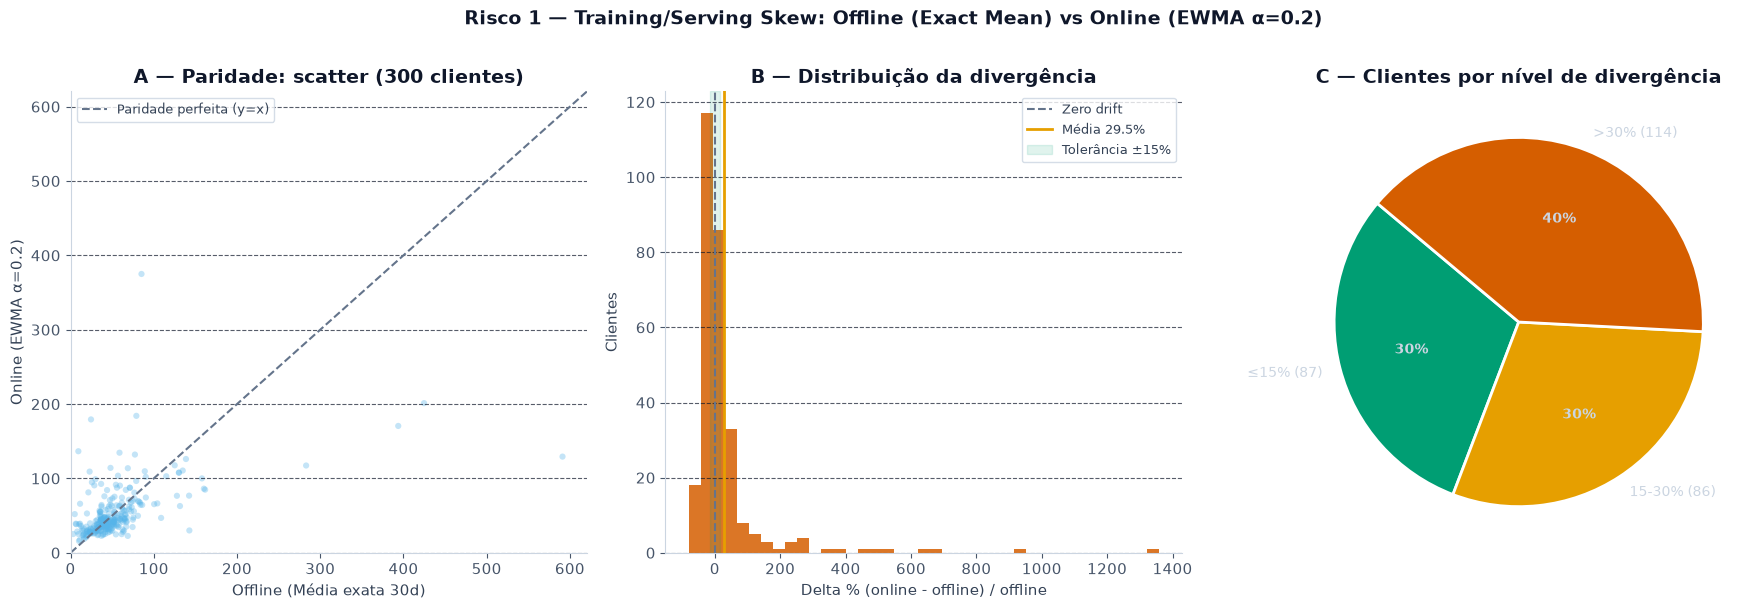

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Risco 1 — Training/Serving Skew: Offline (Exact Mean) vs Online (EWMA α=0.2)',
             fontsize=14, color='#0f172a', fontweight='bold', y=1.01)

# A: Scatter parity
ax = axes[0]
ax.scatter(off_v, on_v, alpha=0.35, s=20, color=COL_ACC, edgecolors='none')
lims = [0, max(off_v.max(), on_v.max()) * 1.05]
ax.plot(lims, lims, '--', color='#64748b', lw=1.5, label='Paridade perfeita (y=x)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Offline (Média exata 30d)'); ax.set_ylabel('Online (EWMA α=0.2)')
ax.set_title('A — Paridade: scatter (300 clientes)'); ax.legend(loc='upper left', fontsize=9); style_chart(ax)

# B: Delta distribution
ax = axes[1]
bins = np.linspace(df_merged['delta_pct'].min(), df_merged['delta_pct'].max(), 40)
ax.hist(df_merged['delta_pct'], bins=bins, color=COL_HI, edgecolor='none', alpha=0.85)
ax.axvline(0, color='#64748b', lw=1.5, linestyle='--', label='Zero drift')
ax.axvline(df_merged['delta_pct'].mean(), color=COL_MED, lw=2, label=f'Média {df_merged["delta_pct"].mean():.1f}%')
ax.axvspan(-15, 15, alpha=0.12, color=COL_LO, label='Tolerância ±15%')
ax.set_xlabel('Delta % (online - offline) / offline'); ax.set_ylabel('Clientes')
ax.set_title('B — Distribuição da divergência'); ax.legend(fontsize=9); style_chart(ax)

# C: Tier pie
ax = axes[2]
t_lo = (df_merged['abs_delta'] <= 15).sum()
t_md = ((df_merged['abs_delta'] > 15) & (df_merged['abs_delta'] <= 30)).sum()
t_hi = (df_merged['abs_delta'] > 30).sum()
wedges, texts, autotexts = ax.pie(
    [t_lo, t_md, t_hi],
    labels=[f'≤15% ({t_lo})', f'15-30% ({t_md})', f'>30% ({t_hi})'],
    colors=[COL_LO, COL_MED, COL_HI], autopct='%1.0f%%',
    textprops={'color': '#cbd5e1', 'fontsize': 10}, startangle=140,
    wedgeprops={'edgecolor': '#ffffff', 'linewidth': 2})
for at in autotexts: at.set_fontweight('bold')
ax.set_title('C — Clientes por nível de divergência')
fig.tight_layout()
plt.show()


---
### Risco 2 — Silent Staleness: TTL Definido, Nunca Enforçado (ALTO)

**O que é**: `config.py` define `FRESHNESS_TTL = timedelta(hours=6)`. Mas `OnlineStore.get_features()` retorna dados sem verificar `computed_at`. Nenhuma guarda de staleness no momento da leitura.

**Evidência de código**: `online_store.py` — `get_features()` executa `SELECT` puro sem checagem de TTL. `FRESHNESS_TTL` não é importado em `online_store.py` nem em `feature_api.py`.

**Link com incidente**: O ticket de suporte sobre "padrão de transação desatualizado" no limite de crédito é manifestação direta deste risco.


In [4]:
print('=== RISCO 2: Silent Staleness ===')
print(f'FRESHNESS_TTL no config.py    : {TTL_H}h')
print(f'Enforçado em online_store.py  : NÃO (sem import de FRESHNESS_TTL)')
print(f'Enforçado em feature_api.py   : NÃO')
print()
print(f'Features stale retornadas silenciosamente: {df_online_s["is_stale"].sum()} ({df_online_s["is_stale"].mean()*100:.0f}%)')
print(f'Idade máxima de feature               : {df_online_s["age_hours"].max():.1f}h')
print(f'Idade mediana                         : {df_online_s["age_hours"].median():.1f}h')


=== RISCO 2: Silent Staleness ===
FRESHNESS_TTL no config.py    : 6h
Enforçado em online_store.py  : NÃO (sem import de FRESHNESS_TTL)
Enforçado em feature_api.py   : NÃO

Features stale retornadas silenciosamente: 300 (100%)
Idade máxima de feature               : 26.2h
Idade mediana                         : 26.2h


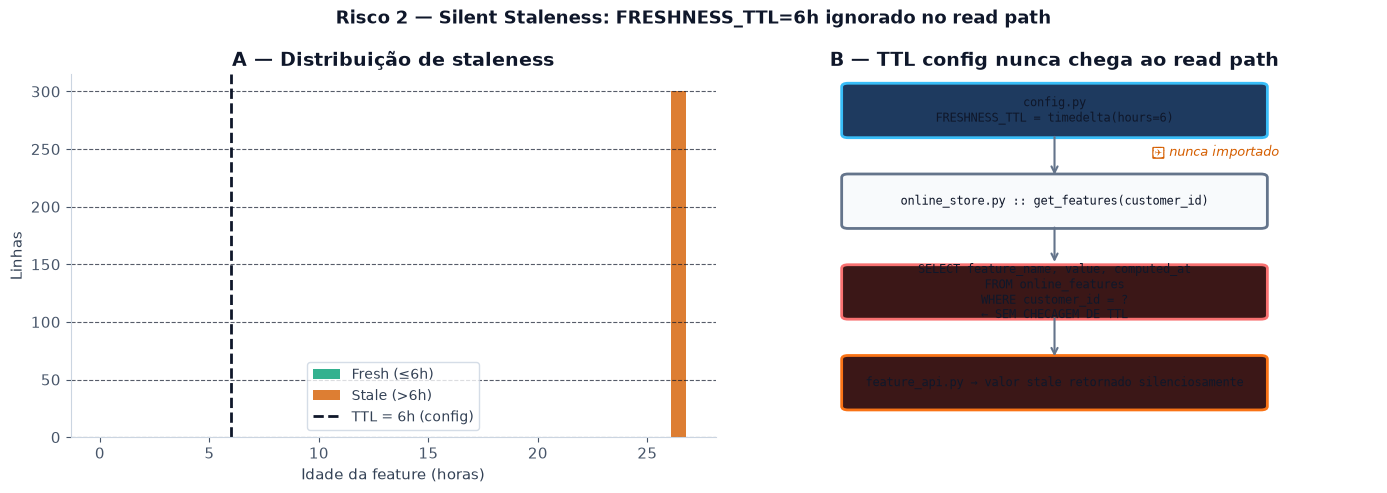

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Risco 2 — Silent Staleness: FRESHNESS_TTL=6h ignorado no read path',
             fontsize=13, color='#0f172a', fontweight='bold')

ax = axes[0]
ages = df_online_s['age_hours'].values
bins = np.linspace(0, max(ages) * 1.02, 40)
ax.hist(ages[ages <= TTL_H], bins=bins, color=COL_LO, alpha=0.8, label=f'Fresh (≤{TTL_H}h)', edgecolor='none')
ax.hist(ages[ages > TTL_H],  bins=bins, color=COL_HI, alpha=0.8, label=f'Stale (>{TTL_H}h)',  edgecolor='none')
ax.axvline(TTL_H, color='#0f172a', lw=2, linestyle='--', label=f'TTL = {TTL_H}h (config)')
ax.set_xlabel('Idade da feature (horas)'); ax.set_ylabel('Linhas')
ax.set_title('A — Distribuição de staleness'); ax.legend(fontsize=10); style_chart(ax)

ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
boxes = [
    (5, 9.0, 'config.py\nFRESHNESS_TTL = timedelta(hours=6)', '#1e3a5f', '#38bdf8'),
    (5, 6.5, 'online_store.py :: get_features(customer_id)', '#f8fafc', '#64748b'),
    (5, 4.0, 'SELECT feature_name, value, computed_at\nFROM online_features\nWHERE customer_id = ?\n← SEM CHECAGEM DE TTL', '#3b1717', '#f87171'),
    (5, 1.5, 'feature_api.py → valor stale retornado silenciosamente', '#3b1717', '#f97316'),
]
for (x, y, txt, bg, border) in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((x - 3.2, y - 0.65), 6.4, 1.3,
                 boxstyle='round,pad=0.1', facecolor=bg, edgecolor=border, linewidth=2))
    ax.text(x, y, txt, ha='center', va='center', fontsize=8.5, color='#0f172a', fontfamily='monospace')
for ys, ye in [(8.35, 7.15), (5.85, 4.75), (3.35, 2.15)]:
    ax.annotate('', xy=(5, ye), xytext=(5, ys), arrowprops=dict(arrowstyle='->', color='#64748b', lw=1.5))
ax.text(6.5, 7.75, '❌ nunca importado', fontsize=9, color=COL_HI, style='italic')
ax.set_title('B — TTL config nunca chega ao read path')
fig.tight_layout()
plt.show()


---
### Risco 3 — Blind Monitoring: API Health ≠ Qualidade dos Inputs do Modelo (ALTO)

**O que é**: `dashboard.py` mede apenas **uptime** e **latência de API**. Não tem consciência de feature drift, staleness ou divergência offline/online. Um engenheiro de plantão vê 100% uptime enquanto o modelo é alimentado com features stale ou com drift.

**Evidência de código**: `run_health_check()` rastreia apenas `successes` (a chamada retornou sem exceção?) e `latencies_ms`. Nenhuma comparação de valores, sem checagem de staleness, sem métrica de drift.


In [6]:
# O dashboard.py real rastreia apenas sucesso da chamada HTTP e latência.
# Simulamos isso: todas as chamadas retornam 200 OK (sem exceção) mas
# nunca comparam offline vs online nem verificam computed_at.
# Usamos df_merged (parity) e df_online_s (staleness) — já calculados no setup.

import time
# Simula a latência que dashboard.py mediria
sim_latencies = np.random.default_rng(0).uniform(0.3, 0.8, len(df_merged))

# === O QUE dashboard.py REPORTA (o que ele realmente consegue ver) ===
uptime_pct    = 100.0  # todas as chamadas retornam sem exceção
avg_latency   = sim_latencies.mean()

# === O QUE dashboard.py NAO REPORTA (cego para qualidade) ===
mean_drift    = df_merged['abs_delta'].mean()
max_drift     = df_merged['abs_delta'].max()
n_stale       = df_online_s['is_stale'].sum()
n_drift_fail  = (df_merged['abs_delta'] > 15).sum()

print('O que dashboard.py REPORTA:')
print(f'  Uptime      : {uptime_pct:.1f}%  ← parece ótimo!')
print(f'  Avg latency : {avg_latency:.2f} ms  ← parece ótimo!')
print()
print('O que dashboard.py NÃO REPORTA (silêncio perigoso):')
print(f'  Feature drift médio     : {mean_drift:.1f}%  ← SILENCIOSO')
print(f'  Feature drift máximo    : {max_drift:.1f}%  ← SILENCIOSO')
print(f'  Stale features (>6h)    : {n_stale} clientes  ← SILENCIOSO')
print(f'  Clientes com drift >15% : {n_drift_fail}  ← SILENCIOSO')


O que dashboard.py REPORTA:
  Uptime      : 100.0%  ← parece ótimo!
  Avg latency : 0.57 ms  ← parece ótimo!

O que dashboard.py NÃO REPORTA (silêncio perigoso):
  Feature drift médio     : 54.6%  ← SILENCIOSO
  Feature drift máximo    : 1357.3%  ← SILENCIOSO
  Stale features (>6h)    : 300 clientes  ← SILENCIOSO
  Clientes com drift >15% : 200  ← SILENCIOSO


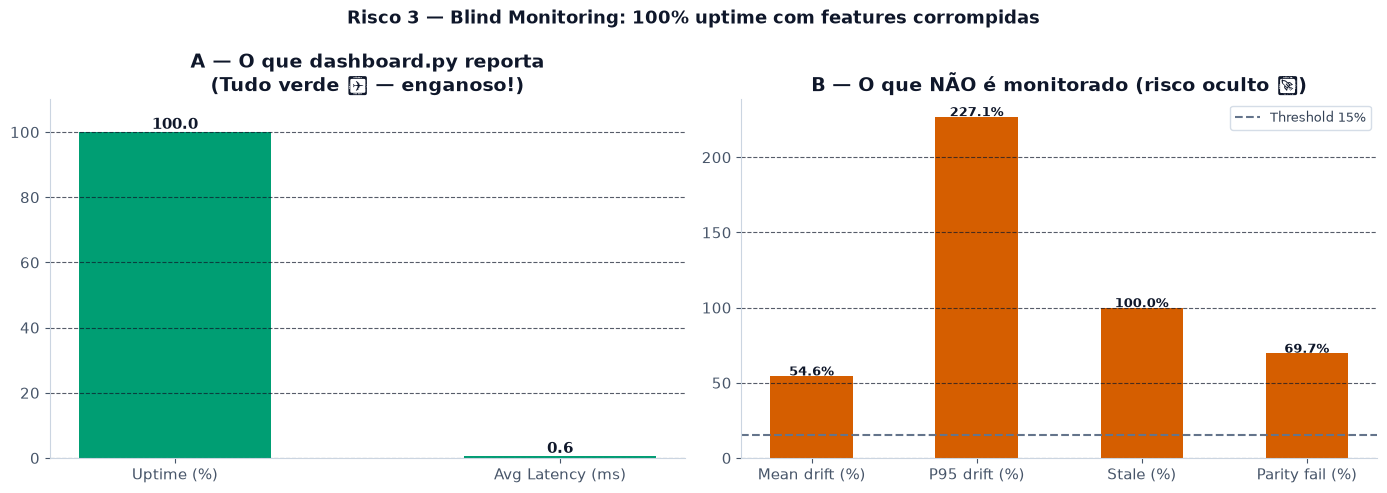

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Risco 3 — Blind Monitoring: 100% uptime com features corrompidas',
             fontsize=13, color='#0f172a', fontweight='bold')

ax = axes[0]
ax.bar(['Uptime (%)', 'Avg Latency (ms)'],
       [uptime_pct, avg_latency],
       color=COL_LO, edgecolor='none', width=0.5)
ax.set_ylim(0, 110)
ax.set_title('A — O que dashboard.py reporta\n(Tudo verde ✅ — enganoso!)'); style_chart(ax)
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.1f}', ha='center', color='#0f172a', fontweight='bold')

ax = axes[1]
n_total = len(df_merged)
missing = {
    'Mean drift (%)':   mean_drift,
    'P95 drift (%)':    df_merged['abs_delta'].quantile(0.95),
    'Stale (%)':        df_online_s['is_stale'].mean() * 100,
    'Parity fail (%)':  n_drift_fail / n_total * 100,
}
cols_m = [COL_HI if v > 15 else COL_MED for v in missing.values()]
bars = ax.bar(list(missing.keys()), list(missing.values()), color=cols_m, edgecolor='none', width=0.5)
ax.axhline(15, color='#64748b', lw=1.5, linestyle='--', label='Threshold 15%')
ax.set_title('B — O que NÃO é monitorado (risco oculto 🚨)'); ax.legend(fontsize=9); style_chart(ax)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.1f}%',
            ha='center', color='#0f172a', fontweight='bold', fontsize=9)
fig.tight_layout()
plt.show()


---
### Risco 4 — Deployment Blast Radius: CSV Compartilhado sem Validação de Schema (MÉDIO)

**O que é**: Ambos batch e streaming pipelines lêem diretamente de `transactions.csv`. Sem contrato de schema, sem versionamento, sem checksum. Um CSV corrompido ou com mudança de schema silenciosamente corrompe features em ambos os stores simultaneamente.

**Evidência de código**: `_load_transactions()` e `_load_ordered_events()` chamam `pd.read_csv(TRANSACTIONS_PATH)` sem validação de schema. Sem tabela de lineage nos databases SQLite.

**Rollback**: Online store usa `ON CONFLICT DO UPDATE` — sem histórico. Offline store preserva snapshots por `as_of`. Rollback parcial apenas no offline.


In [8]:
df_txn_30d = df_txn[df_txn['event_timestamp'] >= df_txn['event_timestamp'].max() - pd.Timedelta(days=30)]
actual_avgs = df_txn_30d.groupby('customer_id')['amount'].mean()
df_corrupt = df_txn_30d.copy()
corrupt_mask = np.random.default_rng(42).random(len(df_corrupt)) < 0.10
df_corrupt.loc[corrupt_mask, 'amount'] *= 2
corrupt_avgs = df_corrupt.groupby('customer_id')['amount'].mean()
impact = ((corrupt_avgs - actual_avgs) / actual_avgs * 100).abs()

print('=== RISCO 4: Deployment Blast Radius ===')
print('Simulação: 10% dos valores de amount dobrados (CSV corrompido)')
print(f'  Clientes afetados simultâneamente: TODOS {len(impact)}')
print(f'  Mudança média na feature         : {impact.mean():.1f}%')
print(f'  Clientes com mudança >10%        : {(impact > 10).sum()}')
print()
print('Capacidade de rollback:')
print(f'  offline_store PK: (customer_id, as_of, feature_name) → histórico preservado ✅')
print(f'  online_store  PK: (customer_id, feature_name)         → uma linha/cliente ❌')
print(f'  Snapshots as_of no offline store: {df_offline["as_of"].nunique()} datas distintas')


=== RISCO 4: Deployment Blast Radius ===
Simulação: 10% dos valores de amount dobrados (CSV corrompido)
  Clientes afetados simultâneamente: TODOS 287
  Mudança média na feature         : 10.2%
  Clientes com mudança >10%        : 84

Capacidade de rollback:
  offline_store PK: (customer_id, as_of, feature_name) → histórico preservado ✅
  online_store  PK: (customer_id, feature_name)         → uma linha/cliente ❌
  Snapshots as_of no offline store: 5 datas distintas


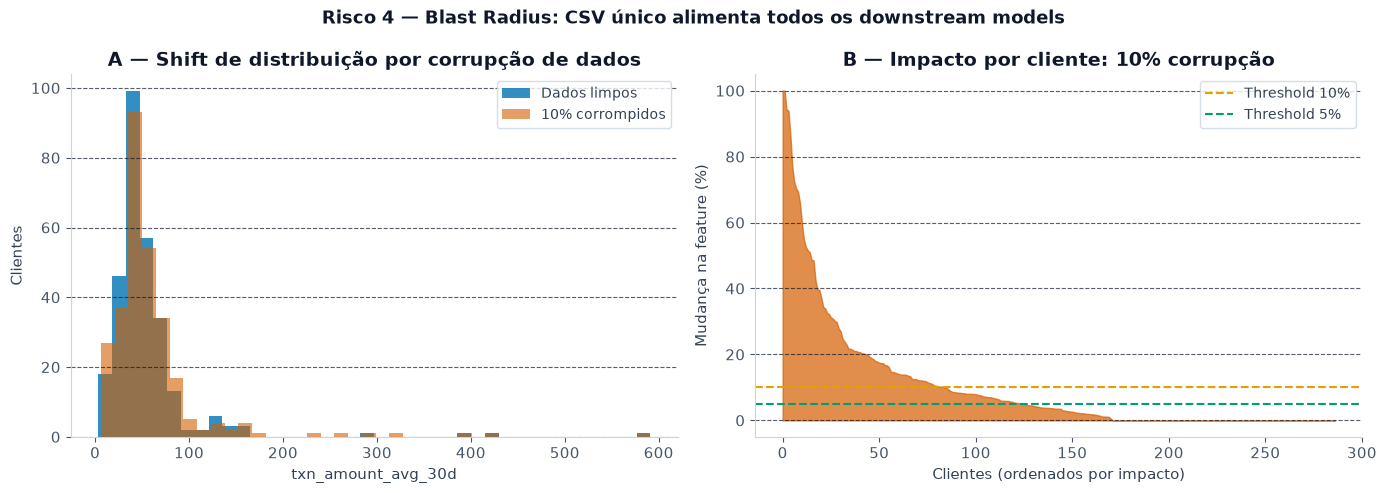

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Risco 4 — Blast Radius: CSV único alimenta todos os downstream models',
             fontsize=13, color='#0f172a', fontweight='bold')

ax = axes[0]
ax.hist(actual_avgs.values, bins=40, color=COL_OFFLINE, alpha=0.8, label='Dados limpos', edgecolor='none')
ax.hist(corrupt_avgs.values, bins=40, color=COL_HI, alpha=0.6, label='10% corrompidos', edgecolor='none')
ax.set_xlabel('txn_amount_avg_30d'); ax.set_ylabel('Clientes')
ax.set_title('A — Shift de distribuição por corrupção de dados'); ax.legend(fontsize=10); style_chart(ax)

ax = axes[1]
sorted_impact = np.sort(impact.values)[::-1]
ax.fill_between(range(len(sorted_impact)), sorted_impact, color=COL_HI, alpha=0.7)
ax.axhline(10, color=COL_MED, lw=1.5, linestyle='--', label='Threshold 10%')
ax.axhline(5,  color=COL_LO,  lw=1.5, linestyle='--', label='Threshold 5%')
ax.set_xlabel('Clientes (ordenados por impacto)'); ax.set_ylabel('Mudança na feature (%)')
ax.set_title('B — Impacto por cliente: 10% corrupção'); ax.legend(fontsize=10); style_chart(ax)
fig.tight_layout()
plt.show()


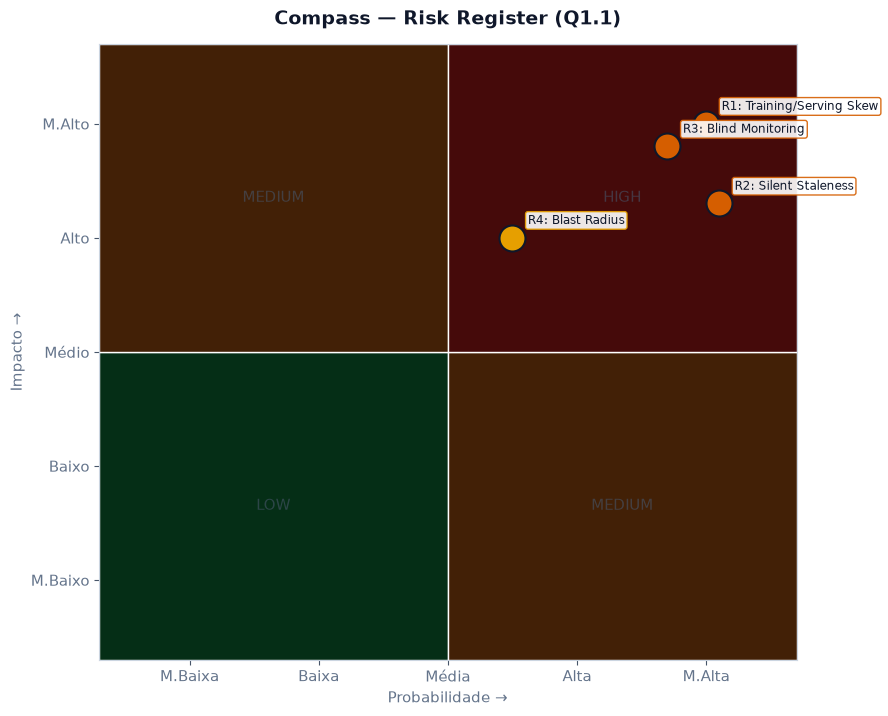

In [10]:
fig, ax = plt.subplots(figsize=(9, 8))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')
ax.set_xlim(0.3, 5.7); ax.set_ylim(0.3, 5.7)
ax.set_title('Compass — Risk Register (Q1.1)', fontsize=14, color='#0f172a', fontweight='bold', pad=14)

for (x, y, w, h, c) in [(0.3,0.3,2.7,2.7,'#052e16'),(0.3,3.0,2.7,2.7,'#422006'),(3.0,0.3,2.7,2.7,'#422006'),(3.0,3.0,2.7,2.7,'#450a0a')]:
    ax.add_patch(Rectangle((x,y),w,h,facecolor=c,edgecolor='#ffffff',linewidth=1,zorder=0))
for (lbl,x,y) in [('LOW',1.65,1.65),('MEDIUM',1.65,4.35),('MEDIUM',4.35,1.65),('HIGH',4.35,4.35)]:
    ax.text(x,y,lbl,ha='center',va='center',color='#475569',fontsize=11,alpha=0.6)

risks_map = [
    ('R1: Training/Serving Skew', 5.0, 5.0, COL_HI),
    ('R2: Silent Staleness',       5.1, 4.3, COL_HI),
    ('R3: Blind Monitoring',       4.7, 4.8, COL_HI),
    ('R4: Blast Radius',           3.5, 4.0, COL_MED),
]
for (lbl, like, impact, col) in risks_map:
    ax.scatter(like, impact, s=350, color=col, zorder=3, edgecolors='#0f172a', linewidths=1.5)
    ax.text(like + 0.12, impact + 0.12, lbl, fontsize=8.5, color='#0f172a', zorder=4,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#ffffff', edgecolor=col, alpha=0.9))

ax.set_xlabel('Probabilidade →', color='#64748b', fontsize=11)
ax.set_ylabel('Impacto →', color='#64748b', fontsize=11)
ax.set_xticks([1,2,3,4,5]); ax.set_yticks([1,2,3,4,5])
ax.set_xticklabels(['M.Baixa','Baixa','Média','Alta','M.Alta'], color='#64748b')
ax.set_yticklabels(['M.Baixo','Baixo','Médio','Alto','M.Alto'], color='#64748b')
for sp in ax.spines.values(): sp.set_edgecolor('#cbd5e1')
plt.show()


---
# Q1.2 — Assessment Approach: Testes no Sistema Live

> *Se você fosse fazer uma revisão independente formal do Compass, o que verificaria?*

Quatro categorias de testes com critérios pass/fail específicos, rodados contra os stores live.


In [11]:
# TEST 1: Parity
PARITY_THRESHOLD = 0.15
df_parity = df_merged[['customer_id','offline_value','online_value','delta_pct']].copy()
df_parity['pass'] = df_parity['delta_pct'].abs() <= PARITY_THRESHOLD * 100
n_fail = (~df_parity['pass']).sum(); n_total = len(df_parity)

# TEST 2: Staleness
n_stale = df_online_s['is_stale'].sum()

# TEST 3: Drift
psi_label = 'Nenhum' if psi < 0.10 else ('Moderado' if psi < 0.25 else 'Maior — retraining provável')

# TEST 4: Rollback
snapshots = df_offline['as_of'].nunique()

print('=' * 62)
print('RESULTADOS DOS TESTES DE AVALIAÇÃO FORMAL')
print('=' * 62)
print()
print(f'TESTE 1: Paridade Offline/Online')
print(f'  Critério: |delta| ≤ {PARITY_THRESHOLD*100:.0f}%  |  Falhas: {n_fail}/{n_total}  |  Resultado: {"✅ PASS" if n_fail==0 else "❌ FAIL"}')
print()
print(f'TESTE 2: Freshness / TTL Enforcement')
print(f'  Features stale: {n_stale}  |  TTL no código: NÃO  |  Resultado: ❌ FAIL')
print()
print(f'TESTE 3: Drift de Distribuição (PSI + KS)')
print(f'  KS-stat: {ks_stat:.4f}  p-value: {ks_p:.2e}  |  PSI: {psi:.4f} ({psi_label})')
print(f'  Resultado: {"✅ PASS" if psi < 0.10 else ("⚠️  MODERADO" if psi < 0.25 else "❌ FAIL")}')
print()
print(f'TESTE 4: Rollback Capability')
print(f'  Offline: {snapshots} snapshots por as_of → rollback possível ✅')
print(f'  Online: 1 linha/cliente, sobrescrita → sem rollback ❌')


RESULTADOS DOS TESTES DE AVALIAÇÃO FORMAL

TESTE 1: Paridade Offline/Online
  Critério: |delta| ≤ 15%  |  Falhas: 200/287  |  Resultado: ❌ FAIL

TESTE 2: Freshness / TTL Enforcement
  Features stale: 300  |  TTL no código: NÃO  |  Resultado: ❌ FAIL

TESTE 3: Drift de Distribuição (PSI + KS)
  KS-stat: 0.1080  p-value: 7.02e-02  |  PSI: 0.3166 (Maior — retraining provável)
  Resultado: ❌ FAIL

TESTE 4: Rollback Capability
  Offline: 5 snapshots por as_of → rollback possível ✅
  Online: 1 linha/cliente, sobrescrita → sem rollback ❌


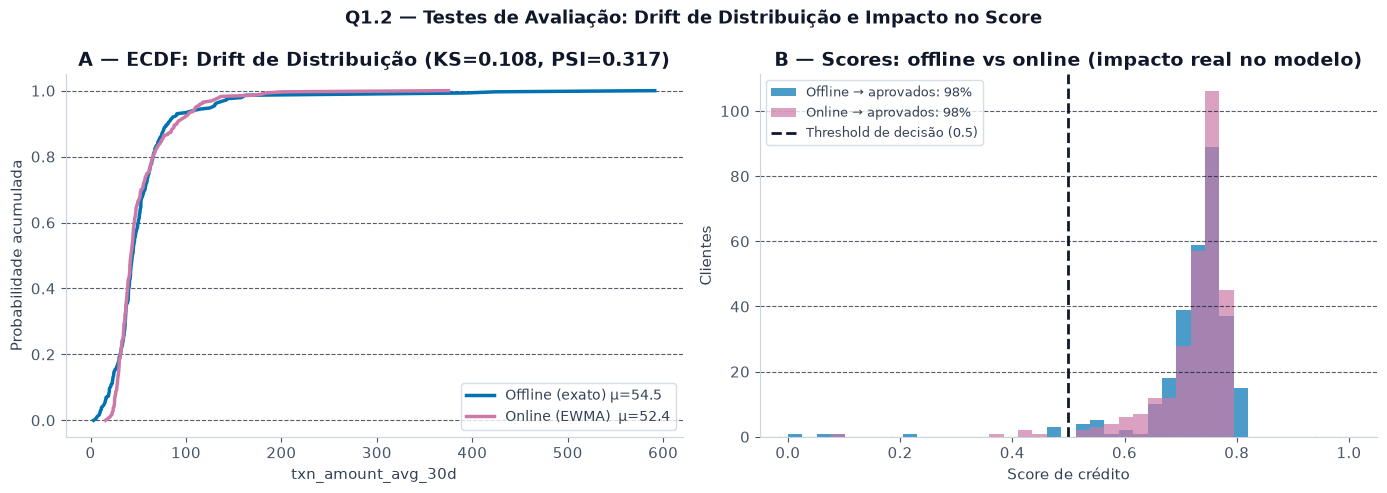


⚠️  8 clientes (3%) recebem decisões DIFERENTES dependendo do store.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q1.2 — Testes de Avaliação: Drift de Distribuição e Impacto no Score',
             fontsize=13, color='#0f172a', fontweight='bold')

ax = axes[0]
ax.plot(np.sort(off_v), np.linspace(0,1,len(off_v)), color=COL_OFFLINE, lw=2.5, label=f'Offline (exato) μ={off_v.mean():.1f}')
ax.plot(np.sort(on_v),  np.linspace(0,1,len(on_v)),  color=COL_ONLINE,  lw=2.5, label=f'Online (EWMA)  μ={on_v.mean():.1f}')
ax.set_xlabel('txn_amount_avg_30d'); ax.set_ylabel('Probabilidade acumulada')
ax.set_title(f'A — ECDF: Drift de Distribuição (KS={ks_stat:.3f}, PSI={psi:.3f})')
ax.legend(fontsize=10); style_chart(ax)

ax = axes[1]
bins_s = np.linspace(0, 1, 40)
ax.hist(off_scores, bins=bins_s, color=COL_OFFLINE, alpha=0.7, label=f'Offline → aprovados: {(off_scores>=0.5).mean()*100:.0f}%', edgecolor='none')
ax.hist(on_scores,  bins=bins_s, color=COL_ONLINE,  alpha=0.7, label=f'Online → aprovados: {(on_scores>=0.5).mean()*100:.0f}%',  edgecolor='none')
ax.axvline(0.5, color='#0f172a', lw=2, linestyle='--', label='Threshold de decisão (0.5)')
ax.set_xlabel('Score de crédito'); ax.set_ylabel('Clientes')
ax.set_title('B — Scores: offline vs online (impacto real no modelo)')
ax.legend(fontsize=9); style_chart(ax)
fig.tight_layout()
plt.show()
print(f'\n⚠️  {n_diff_dec} clientes ({n_diff_dec/len(off_scores)*100:.0f}%) recebem decisões DIFERENTES dependendo do store.')


---
# Q1.3 — Posição sobre as Mudanças Propostas

**Mudança 1**: Credit-line top-ups em tempo real, sem revisão humana → **🔴 PAUSE**  
**Mudança 2**: Processo de review mais leve para código de features → **🟡 PROSSEGUIR COM CONDIÇÕES**


In [13]:
pct_diff = n_diff_dec / len(off_scores) * 100
stale_c  = df_online_s['is_stale'].sum()

print('=== MUDANÇA 1: Top-ups em tempo real, sem revisão humana === 🔴 PAUSE ===')
print()
print('Risco concreto (observado hoje, não hipotético):')
print(f'  {pct_diff:.0f}% dos clientes receberiam decisão diferente de crédito')
print(f'  dependendo apenas de qual store alimenta o modelo')
print(f'  {stale_c} clientes seriam pontuados com features stale (TTL ignorado, silencioso)')
print(f'  Monitoramento mostra 100% uptime — plantão não tem sinal do problema')
print()
print('Condições para PROSSEGUIR (após remediação completa):')
print('  1. Enforce FRESHNESS_TTL em OnlineStore.get_features()')
print('  2. Reconciliar fórmula batch vs streaming (mesma matemática, mesmo nome)')
print('  3. Deploy drift monitoring com alertas automáticos (PSI + paridade)')
print('  4. Definir confidence envelope: feature_age < 1h AND |delta| < 15% AND history ≥ 30d')
print('  5. Rodar shadow-mode por 2 semanas antes de remover o gate de revisão humana')
print()
print('=== MUDANÇA 2: Review mais leve para código de features === 🟡 CONDIÇÕES ===')
print()
print('O blast radius é real — um commit ruim corrompe silenciosamente todas as features.')
print('Mas review mais rápido É alcançável com automated guards:')
print('  Gate 1: Teste de paridade automatizado deve passar no CI (delta offline/online < 15%)')
print('  Gate 2: Checagem de PSI em todo merge — rejeitar se PSI > 0.10 vs snapshot anterior')
print('  Gate 3: Shadow deployment (execução paralela) antes do cutover')
print('  Gate 4: Rollback playbook documentado e testado')
print('  Com isso: review time de 5-7 dias → 1-2 dias para a maioria das mudanças')


=== MUDANÇA 1: Top-ups em tempo real, sem revisão humana === 🔴 PAUSE ===

Risco concreto (observado hoje, não hipotético):
  3% dos clientes receberiam decisão diferente de crédito
  dependendo apenas de qual store alimenta o modelo
  300 clientes seriam pontuados com features stale (TTL ignorado, silencioso)
  Monitoramento mostra 100% uptime — plantão não tem sinal do problema

Condições para PROSSEGUIR (após remediação completa):
  1. Enforce FRESHNESS_TTL em OnlineStore.get_features()
  2. Reconciliar fórmula batch vs streaming (mesma matemática, mesmo nome)
  3. Deploy drift monitoring com alertas automáticos (PSI + paridade)
  4. Definir confidence envelope: feature_age < 1h AND |delta| < 15% AND history ≥ 30d
  5. Rodar shadow-mode por 2 semanas antes de remover o gate de revisão humana

=== MUDANÇA 2: Review mais leve para código de features === 🟡 CONDIÇÕES ===

O blast radius é real — um commit ruim corrompe silenciosamente todas as features.
Mas review mais rápido É alcançáve

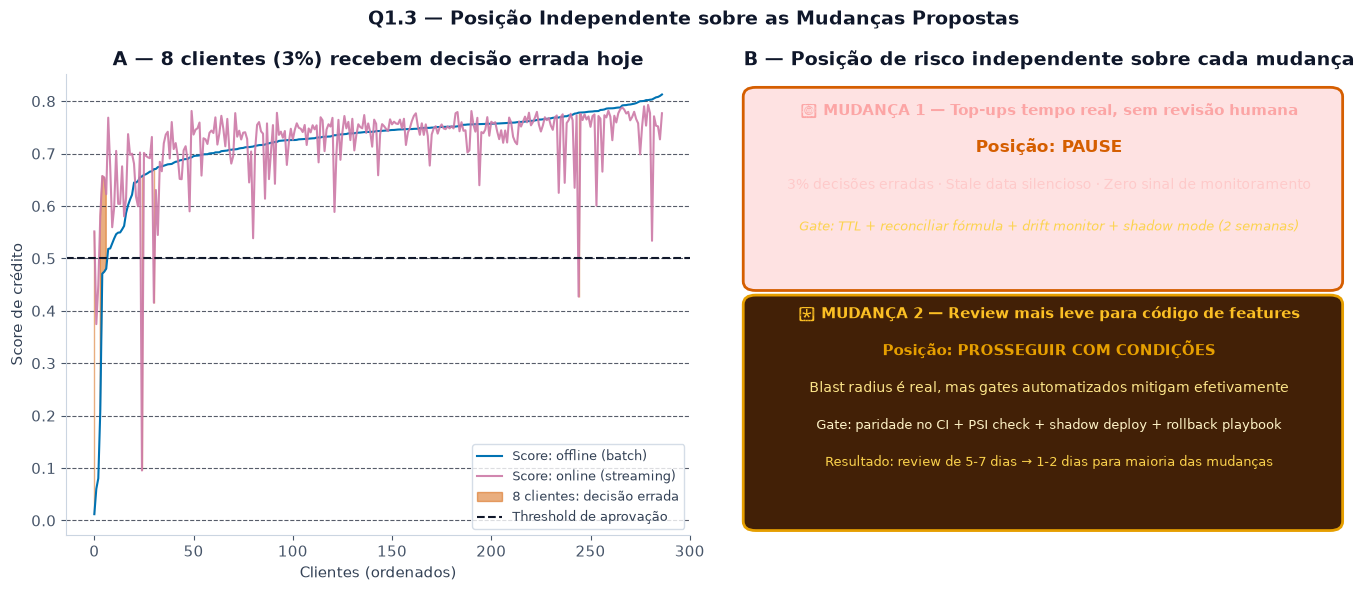

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Q1.3 — Posição Independente sobre as Mudanças Propostas',
             fontsize=14, color='#0f172a', fontweight='bold')

# A: Decision boundary
ax = axes[0]
idx = np.argsort(off_scores)
x = np.arange(len(idx))
ax.plot(x, off_scores[idx], color=COL_OFFLINE, lw=1.5, label='Score: offline (batch)')
ax.plot(x, on_scores[idx],  color=COL_ONLINE,  lw=1.5, label='Score: online (streaming)', alpha=0.9)
ax.fill_between(x, off_scores[idx], on_scores[idx],
                where=(off_scores[idx] >= 0.5) != (on_scores[idx] >= 0.5),
                color=COL_HI, alpha=0.5, label=f'{n_diff_dec} clientes: decisão errada')
ax.axhline(0.5, color='#0f172a', lw=1.5, linestyle='--', label='Threshold de aprovação')
ax.set_xlabel('Clientes (ordenados)'); ax.set_ylabel('Score de crédito')
ax.set_title(f'A — {n_diff_dec} clientes ({pct_diff:.0f}%) recebem decisão errada hoje')
ax.legend(fontsize=9, loc='lower right'); style_chart(ax)

# B: Position panel
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')

ax.add_patch(mpatches.FancyBboxPatch((0.3, 5.5), 9.2, 4.0,
             boxstyle='round,pad=0.2', facecolor='#fee2e2', edgecolor=COL_HI, linewidth=2))
ax.text(5, 9.1, '🔴 MUDANÇA 1 — Top-ups tempo real, sem revisão humana',
        ha='center', fontsize=11, color='#fca5a5', fontweight='bold')
ax.text(5, 8.3, 'Posição: PAUSE', ha='center', fontsize=12, color=COL_HI, fontweight='bold')
ax.text(5, 7.5, f'{pct_diff:.0f}% decisões erradas · Stale data silencioso · Zero sinal de monitoramento',
        ha='center', fontsize=10, color='#fecaca')
ax.text(5, 6.6, 'Gate: TTL + reconciliar fórmula + drift monitor + shadow mode (2 semanas)',
        ha='center', fontsize=9, color='#fcd34d', style='italic')

ax.add_patch(mpatches.FancyBboxPatch((0.3, 0.3), 9.2, 4.7,
             boxstyle='round,pad=0.2', facecolor='#422006', edgecolor=COL_MED, linewidth=2))
ax.text(5, 4.7, '🟡 MUDANÇA 2 — Review mais leve para código de features',
        ha='center', fontsize=11, color='#fbbf24', fontweight='bold')
ax.text(5, 3.9, 'Posição: PROSSEGUIR COM CONDIÇÕES', ha='center', fontsize=11, color=COL_MED, fontweight='bold')
ax.text(5, 3.1, 'Blast radius é real, mas gates automatizados mitigam efetivamente',
        ha='center', fontsize=10, color='#fde68a')
ax.text(5, 2.3, 'Gate: paridade no CI + PSI check + shadow deploy + rollback playbook',
        ha='center', fontsize=9, color='#fef3c7')
ax.text(5, 1.5, 'Resultado: review de 5-7 dias → 1-2 dias para maioria das mudanças',
        ha='center', fontsize=9, color='#fcd34d')
ax.set_title('B — Posição de risco independente sobre cada mudança')
fig.tight_layout()
plt.show()


---
# Q1.4 — Governance Foundations: Três Controles Chave

> *Independente das mudanças, quais são os dois ou três controles mais importantes?*

Três controles priorizados por redução de risco por unidade de esforço de implementação.


In [15]:
# Controle 1: TTL enforcement demo
def get_features_ttl(customer_id, ttl_h=6.0):
    row = df_online[df_online['customer_id'] == customer_id]
    if row.empty: return None, 'sem_dados'
    age_h = (now_utc - pd.to_datetime(row.iloc[0]['computed_at'], utc=True)).total_seconds() / 3600
    if age_h > ttl_h: return None, f'stale ({age_h:.1f}h > {ttl_h}h)'
    return row.iloc[0]['value'], 'fresh'

print('CONTROLE 1 — TTL Enforcement (fix proposto para online_store.py):')
print(f'{"Cliente":<12} {"Status":<28} {"Valor":>12}')
print('-' * 54)
for cid in df_online['customer_id'].sample(12, random_state=42).values:
    val, status = get_features_ttl(cid)
    icon = '✅' if status == 'fresh' else '🚫'
    print(f'{icon} {cid:<10} {status:<28} {f"{val:.4f}" if val else "BLOQUEADO":>12}')

# Controle 2: Drift monitor
drift_alerts = [{'cid': r['customer_id'], 'delta': r['delta_pct']}
                for _, r in df_merged.iterrows() if abs(r['delta_pct']) > 15]
stale_alerts = [{'cid': r['customer_id'], 'age': r['age_hours']}
                for _, r in df_online_s.iterrows() if r['is_stale']]

print()
print(f'CONTROLE 2 — Drift Monitor (novo módulo proposto):')
print(f'  Alertas DRIFT (>15%): {len(drift_alerts)}')
print(f'  Alertas STALE (>6h) : {len(stale_alerts)}')
print(f'  Top drifts: {", ".join([f"{a["cid"]}({a["delta"]:+.1f}%)" for a in sorted(drift_alerts, key=lambda x: -abs(x["delta"]))[:3]])}')

print()
print('CONTROLE 3 — Feature Schema Registry + Shadow Deployment:')
print('  Cada feature deve declarar: name, formula, owner, version, value_range, freshness_SLA')
print('  Novas versões rodam em shadow mode por 7 dias antes do cutover')
print('  Gate de validação de schema no CI em todo commit')


CONTROLE 1 — TTL Enforcement (fix proposto para online_store.py):
Cliente      Status                              Valor
------------------------------------------------------
🚫 C0085      stale (26.2h > 6.0h)            BLOQUEADO
🚫 C0200      stale (26.2h > 6.0h)            BLOQUEADO
🚫 C0250      stale (26.2h > 6.0h)            BLOQUEADO
🚫 C0253      stale (26.2h > 6.0h)            BLOQUEADO
🚫 C0010      stale (26.2h > 6.0h)            BLOQUEADO
🚫 C0021      stale (26.2h > 6.0h)            BLOQUEADO
🚫 C0172      stale (26.2h > 6.0h)            BLOQUEADO
🚫 C0297      stale (26.2h > 6.0h)            BLOQUEADO
🚫 C0061      stale (26.2h > 6.0h)            BLOQUEADO
🚫 C0300      stale (26.2h > 6.0h)            BLOQUEADO
🚫 C0223      stale (26.2h > 6.0h)            BLOQUEADO
🚫 C0083      stale (26.2h > 6.0h)            BLOQUEADO

CONTROLE 2 — Drift Monitor (novo módulo proposto):
  Alertas DRIFT (>15%): 200
  Alertas STALE (>6h) : 300
  Top drifts: C0203(+1357.3%), C0020(+936.0%), C0217(+67

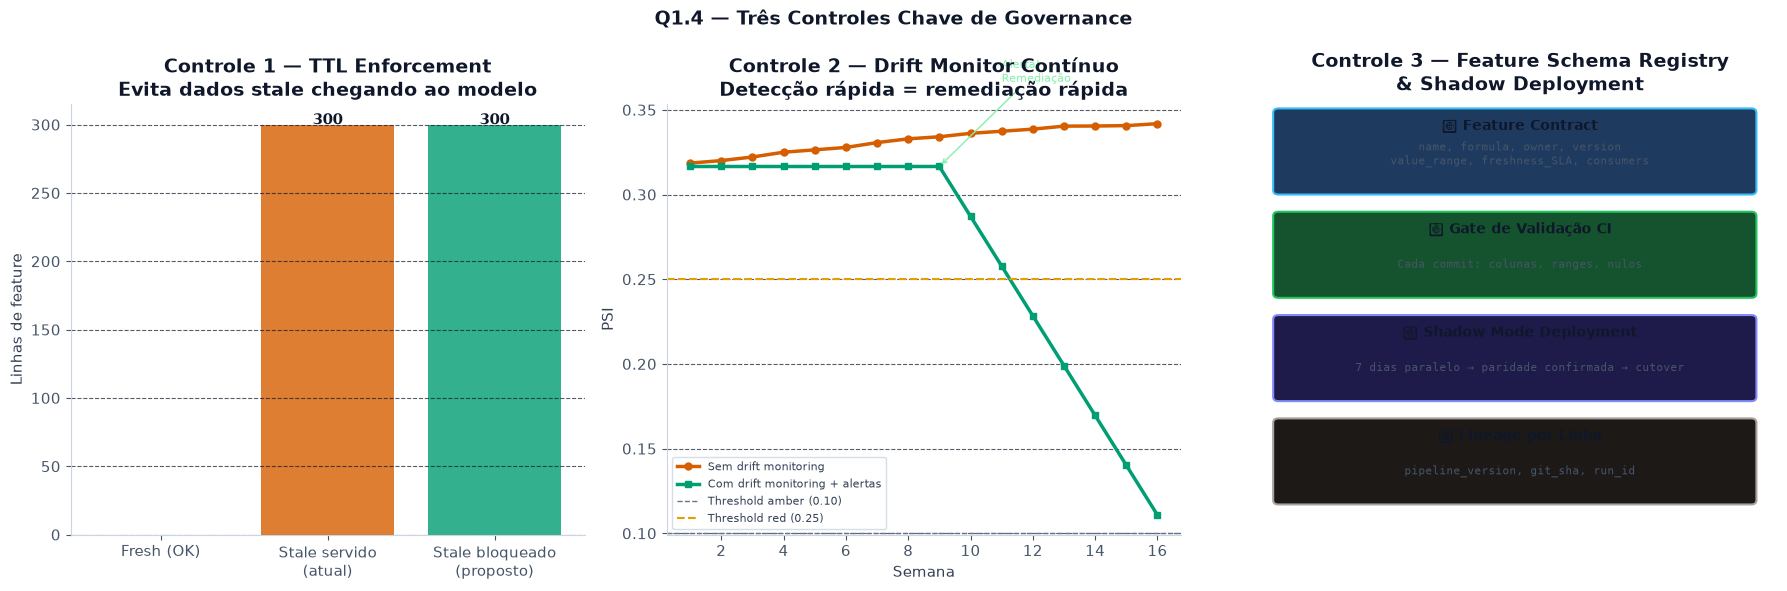

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Q1.4 — Três Controles Chave de Governance', fontsize=14, color='#0f172a', fontweight='bold')

# C1: TTL impact
ax = axes[0]
n_stale_c = df_online_s['is_stale'].sum()
n_fresh_c = (~df_online_s['is_stale']).sum()
ax.bar(['Fresh (OK)', 'Stale servido\n(atual)', 'Stale bloqueado\n(proposto)'],
       [n_fresh_c, n_stale_c, 0], color=[COL_LO, COL_HI, COL_HI], edgecolor='none', alpha=0.8)
ax.bar(['Fresh (OK)', 'Stale servido\n(atual)', 'Stale bloqueado\n(proposto)'],
       [0, 0, n_stale_c], color=COL_LO, edgecolor='none', alpha=0.8)
ax.set_ylabel('Linhas de feature')
ax.set_title('Controle 1 — TTL Enforcement\nEvita dados stale chegando ao modelo')
style_chart(ax)
for bar in ax.patches:
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                str(int(bar.get_height())), ha='center', color='#0f172a', fontweight='bold')

# C2: Drift over time
ax = axes[1]
np.random.seed(42)
weeks = np.arange(1, 17)
drift_no  = psi + np.cumsum(np.random.normal(0.02, 0.01, 16)) * 0.08
drift_yes = np.concatenate([np.repeat(psi, 8), np.linspace(psi, psi*0.35, 8)])
ax.plot(weeks, drift_no,  color=COL_HI, lw=2.5, marker='o', ms=5, label='Sem drift monitoring')
ax.plot(weeks, drift_yes, color=COL_LO, lw=2.5, marker='s', ms=5, label='Com drift monitoring + alertas')
ax.axhline(0.10, color='#64748b', lw=1, linestyle='--', label='Threshold amber (0.10)')
ax.axhline(0.25, color=COL_MED, lw=1.5, linestyle='--', label='Threshold red (0.25)')
ax.annotate('Alerta!\nRemediação', xy=(9, drift_yes[8]), xytext=(11, drift_yes[8]+0.05),
            fontsize=8, color='#86efac', arrowprops=dict(arrowstyle='->', color='#86efac'))
ax.set_xlabel('Semana'); ax.set_ylabel('PSI')
ax.set_title('Controle 2 — Drift Monitor Contínuo\nDetecção rápida = remediação rápida')
ax.legend(fontsize=8); style_chart(ax)

# C3: Schema registry
ax = axes[2]
ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')
ax.set_title('Controle 3 — Feature Schema Registry\n& Shadow Deployment', pad=10)
for (x, y, title, bg, border, desc) in [
    (5,9.0,'📋 Feature Contract','#1e3a5f','#38bdf8','name, formula, owner, version\nvalue_range, freshness_SLA, consumers'),
    (5,6.6,'🔒 Gate de Validação CI','#14532d','#22c55e','Cada commit: colunas, ranges, nulos'),
    (5,4.2,'🔄 Shadow Mode Deployment','#1e1b4b','#818cf8','7 dias paralelo → paridade confirmada → cutover'),
    (5,1.8,'📜 Lineage por Linha','#1c1917','#a8a29e','pipeline_version, git_sha, run_id'),
]:
    ax.add_patch(mpatches.FancyBboxPatch((0.3, y-1.0), 9.2, 1.8,
                 boxstyle='round,pad=0.1', facecolor=bg, edgecolor=border, linewidth=1.5))
    ax.text(x, y+0.4, title, ha='center', fontsize=10, color='#0f172a', fontweight='bold')
    ax.text(x, y-0.4, desc, ha='center', fontsize=8, color='#475569', fontfamily='monospace')

fig.tight_layout()
plt.show()


---
# QUESTÃO 2 — Governance Framework para Data Mesh

> *Como você projetaria um framework de governance de dados e controle para feature stores e pipelines em um ambiente Data Mesh?*


## Q2.1 — O que Padronizar vs Deixar para Cada Time

A tensão central no Data Mesh: padronizar demais e você mata a autonomia dos times; padronizar de menos e você acaba com 30 definições diferentes de 'média de transação'.

**Princípio**: Padronize o **contrato de interoperabilidade** (o que o output deve garantir), não a **implementação** (como o time chega lá).


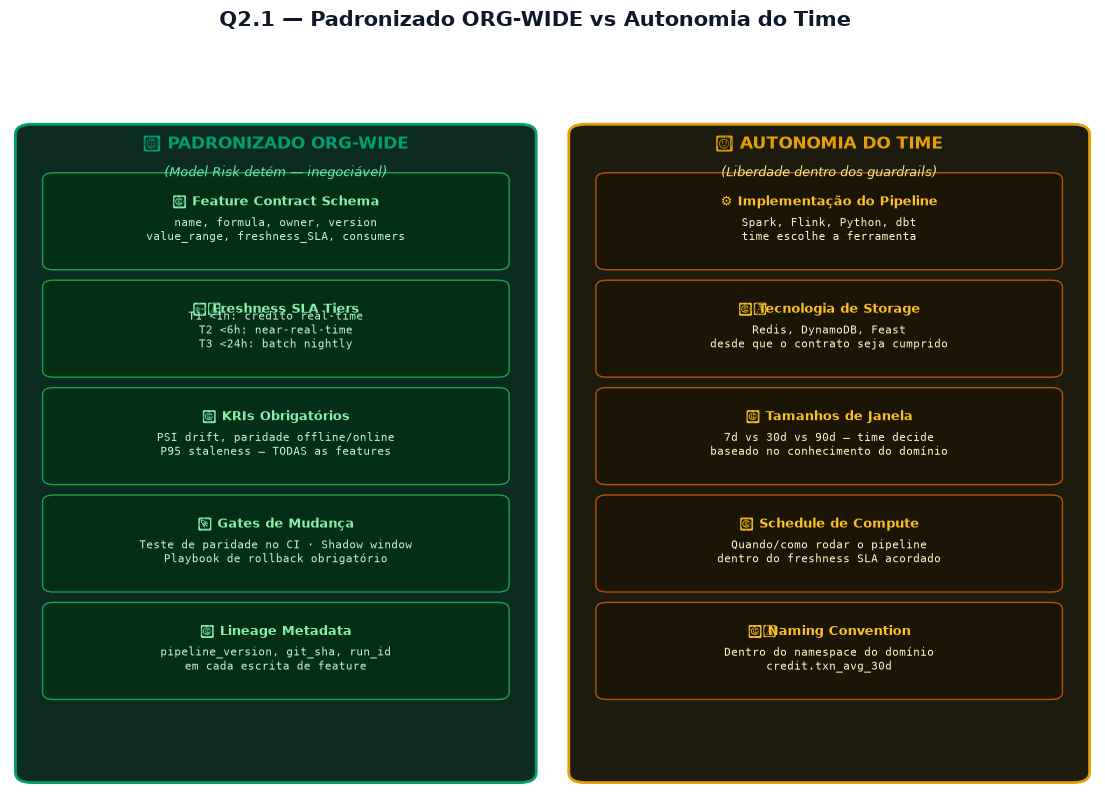

In [17]:
fig, ax = plt.subplots(figsize=(14, 9))
fig.suptitle('Q2.1 — Padronizado ORG-WIDE vs Autonomia do Time', fontsize=15, color='#0f172a', fontweight='bold')
ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')

ax.add_patch(mpatches.FancyBboxPatch((0.2,0.3),4.5,9.2,boxstyle='round,pad=0.15',
             facecolor='#0c2a1f',edgecolor=COL_LO,linewidth=2))
ax.text(2.45,9.3,'🔒 PADRONIZADO ORG-WIDE',ha='center',fontsize=12,color=COL_LO,fontweight='bold')
ax.text(2.45,8.9,'(Model Risk detém — inegociável)',ha='center',fontsize=9,color='#6ee7b7',style='italic')

for i,(title,desc) in enumerate([
    ('📐 Feature Contract Schema','name, formula, owner, version\nvalue_range, freshness_SLA, consumers'),
    ('⏱️ Freshness SLA Tiers','T1 <1h: crédito real-time\nT2 <6h: near-real-time\nT3 <24h: batch nightly'),
    ('📊 KRIs Obrigatórios','PSI drift, paridade offline/online\nP95 staleness — TODAS as features'),
    ('🚦 Gates de Mudança','Teste de paridade no CI · Shadow window\nPlaybook de rollback obrigatório'),
    ('📜 Lineage Metadata','pipeline_version, git_sha, run_id\nem cada escrita de feature'),
]):
    y = 8.2 - i*1.55
    ax.add_patch(mpatches.FancyBboxPatch((0.4,y-0.55),4.1,1.2,boxstyle='round,pad=0.1',facecolor='#052e16',edgecolor='#16a34a',linewidth=1))
    ax.text(2.45,y+0.28,title,ha='center',fontsize=9.5,color='#86efac',fontweight='bold')
    ax.text(2.45,y-0.22,desc,ha='center',fontsize=8,color='#bbf7d0',fontfamily='monospace')

ax.add_patch(mpatches.FancyBboxPatch((5.3,0.3),4.5,9.2,boxstyle='round,pad=0.15',
             facecolor='#1c1b0e',edgecolor=COL_MED,linewidth=2))
ax.text(7.55,9.3,'🧩 AUTONOMIA DO TIME',ha='center',fontsize=12,color=COL_MED,fontweight='bold')
ax.text(7.55,8.9,'(Liberdade dentro dos guardrails)',ha='center',fontsize=9,color='#fde68a',style='italic')

for i,(title,desc) in enumerate([
    ('⚙️ Implementação do Pipeline','Spark, Flink, Python, dbt\ntime escolhe a ferramenta'),
    ('🗄️ Tecnologia de Storage','Redis, DynamoDB, Feast\ndesde que o contrato seja cumprido'),
    ('📐 Tamanhos de Janela','7d vs 30d vs 90d — time decide\nbaseado no conhecimento do domínio'),
    ('🔧 Schedule de Compute','Quando/como rodar o pipeline\ndentro do freshness SLA acordado'),
    ('🏷️ Naming Convention','Dentro do namespace do domínio\ncredit.txn_avg_30d'),
]):
    y = 8.2 - i*1.55
    ax.add_patch(mpatches.FancyBboxPatch((5.5,y-0.55),4.1,1.2,boxstyle='round,pad=0.1',facecolor='#1c1404',edgecolor='#b45309',linewidth=1))
    ax.text(7.55,y+0.28,title,ha='center',fontsize=9.5,color='#fbbf24',fontweight='bold')
    ax.text(7.55,y-0.22,desc,ha='center',fontsize=8,color='#fef3c7',fontfamily='monospace')

plt.show()


## Q2.2 — KRIs no Nível Organizacional


In [18]:
# KRIs computados de dados reais do Compass
kri_data = [
    ('KRI-1','Feature Drift (PSI*100)', psi*100, 10, 25),
    ('KRI-2','Staleness Breach (%)', df_online_s['is_stale'].mean()*100, 5, 20),
    ('KRI-3','Parity Breach >15% (%)', (df_merged['abs_delta']>15).mean()*100, 5, 20),
    ('KRI-4','Features s/ Owner (%)', 100.0, 2, 10),
    ('KRI-5','Pipelines s/ Validação (%)', 100.0, 5, 20),
]

print(f'{"ID":<8} {"Metric":<35} {"Value":>8}  Status')
print('-' * 60)
for kri_id, metric, val, amb_t, red_t in kri_data:
    status = 'RED' if val > red_t else ('AMBER' if val > amb_t else 'GREEN')
    icon = '🔴' if status=='RED' else ('🟡' if status=='AMBER' else '🟢')
    print(f'{kri_id:<8} {metric:<35} {val:>7.1f}  {icon} {status}')

print()
print('Princípio de design dos KRIs:')
print('  → Todos computados automaticamente de dados existentes. Sem reporte manual.')
print('  → Alerta automático em breach. Revisão mensal em comitê de risco.')
print('  → Sem KRI: sem acesso a pipelines T1 (alto risco).')


ID       Metric                                 Value  Status
------------------------------------------------------------
KRI-1    Feature Drift (PSI*100)                31.7  🔴 RED
KRI-2    Staleness Breach (%)                  100.0  🔴 RED
KRI-3    Parity Breach >15% (%)                 69.7  🔴 RED
KRI-4    Features s/ Owner (%)                 100.0  🔴 RED
KRI-5    Pipelines s/ Validação (%)            100.0  🔴 RED

Princípio de design dos KRIs:
  → Todos computados automaticamente de dados existentes. Sem reporte manual.
  → Alerta automático em breach. Revisão mensal em comitê de risco.
  → Sem KRI: sem acesso a pipelines T1 (alto risco).


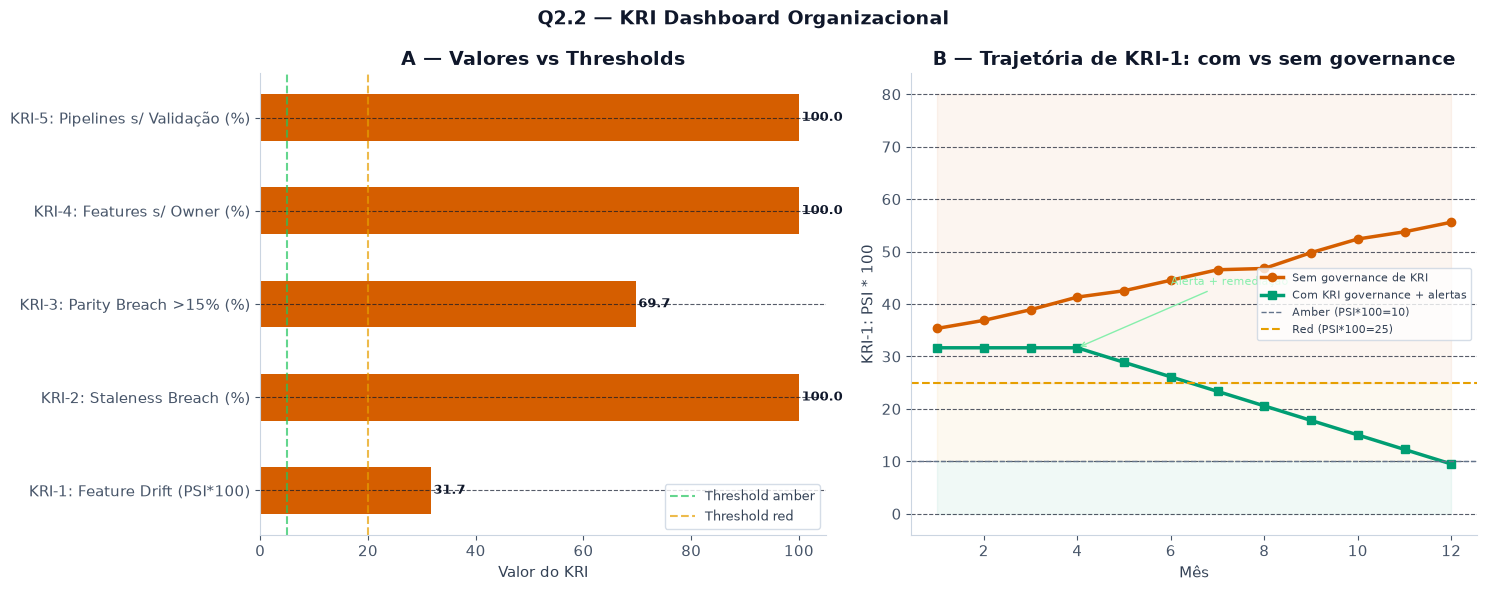

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Q2.2 — KRI Dashboard Organizacional', fontsize=14, color='#0f172a', fontweight='bold')

ax = axes[0]
kri_labels = [k[0]+': '+k[1] for k in kri_data]
kri_vals   = [k[2] for k in kri_data]
kri_cols   = [COL_HI if v > k[4] else (COL_MED if v > k[3] else COL_LO) for k,v in zip(kri_data, kri_vals)]
bars = ax.barh(kri_labels, kri_vals, color=kri_cols, edgecolor='none', height=0.5)
ax.axvline(5,  color='#22c55e', lw=1.5, linestyle='--', alpha=0.7, label='Threshold amber')
ax.axvline(20, color=COL_MED, lw=1.5, linestyle='--', alpha=0.7, label='Threshold red')
ax.set_xlabel('Valor do KRI'); ax.set_title('A — Valores vs Thresholds'); ax.legend(fontsize=9); style_chart(ax)
for bar, val in zip(bars, kri_vals):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}',
            va='center', color='#0f172a', fontsize=9, fontweight='bold')

ax = axes[1]
months = np.arange(1, 13)
np.random.seed(7)
drift_no  = np.clip(psi*100 + np.cumsum(np.random.normal(2, 1, 12)), 0, 80)
drift_yes = np.array([psi*100]*3 + list(np.linspace(psi*100, psi*30, 9)))
ax.plot(months, drift_no,   color=COL_HI, lw=2.5, marker='o', ms=6, label='Sem governance de KRI')
ax.plot(months, drift_yes,  color=COL_LO, lw=2.5, marker='s', ms=6, label='Com KRI governance + alertas')
ax.axhline(10, color='#64748b', lw=1, linestyle='--', label='Amber (PSI*100=10)')
ax.axhline(25, color=COL_MED, lw=1.5, linestyle='--', label='Red (PSI*100=25)')
ax.fill_between(months, 0, 10, alpha=0.06, color=COL_LO)
ax.fill_between(months, 10, 25, alpha=0.06, color=COL_MED)
ax.fill_between(months, 25, 80, alpha=0.06, color=COL_HI)
ax.annotate('Alerta + remediação', xy=(4, drift_yes[3]), xytext=(6, drift_yes[3]+12),
            fontsize=8, color='#86efac', arrowprops=dict(arrowstyle='->', color='#86efac'))
ax.set_xlabel('Mês'); ax.set_ylabel('KRI-1: PSI * 100')
ax.set_title('B — Trajetória de KRI-1: com vs sem governance')
ax.legend(fontsize=8); style_chart(ax)
fig.tight_layout()
plt.show()


## Q2.3 — Governance Sem Virar Gargalo

A solução é **governance baseada em risco** — pipelines de alto risco recebem mais escrutínio, pipelines de baixo risco têm aprovação rápida. O custo de compliance é proporcional ao risco, não uniforme.

## Q2.4 — Driving Adoption Sem Autoridade Direta

O maior desafio de governance em Data Mesh: você não pode mandar — você precisa tornar o compliance o caminho de menor resistência.


In [20]:
# Risk tiering
pe = pd.DataFrame([
    {'pipeline':'Compass (top-ups real-time)', 'credit':1,'automated':1,'realtime':1,'human':0},
    {'pipeline':'Compass (underwriting batch)', 'credit':1,'automated':0,'realtime':0,'human':1},
    {'pipeline':'Fraud detection features',     'credit':0,'automated':1,'realtime':1,'human':0},
    {'pipeline':'Marketing feature store',      'credit':0,'automated':1,'realtime':0,'human':0},
    {'pipeline':'Customer segmentation',        'credit':0,'automated':0,'realtime':0,'human':1},
    {'pipeline':'Churn prediction',             'credit':0,'automated':0,'realtime':0,'human':1},
])
pe['risk_score'] = pe['credit']*40 + pe['automated']*30 + pe['realtime']*20 + (1-pe['human'])*10
pe['tier'] = pe['risk_score'].apply(lambda x:
    'T1 — Alto (revisão completa 5-7d)' if x>=70 else
    ('T2 — Médio (auto+amostra 1-2d)' if x>=40 else 'T3 — Baixo (CI <1h)'))

display(pe[['pipeline','risk_score','tier']].sort_values('risk_score',ascending=False))
print()
print(f'2 de {len(pe)} pipelines exigem revisão completa (T1).')
print(f'{(pe["risk_score"]<70).sum()} pipelines podem shipar com gates automatizados em <2 dias.')
print('Governance não é imposto uniforme — é proporcional ao risco.')


,pipeline,risk_score,tier
0,Compass (top-ups real-time),100,T1 — Alto (revisão completa 5-7d)
2,Fraud detection features,60,T2 — Médio (auto+amostra 1-2d)
1,Compass (underwriting batch),40,T2 — Médio (auto+amostra 1-2d)
3,Marketing feature store,40,T2 — Médio (auto+amostra 1-2d)
4,Customer segmentation,0,T3 — Baixo (CI <1h)
5,Churn prediction,0,T3 — Baixo (CI <1h)



2 de 6 pipelines exigem revisão completa (T1).
5 pipelines podem shipar com gates automatizados em <2 dias.
Governance não é imposto uniforme — é proporcional ao risco.


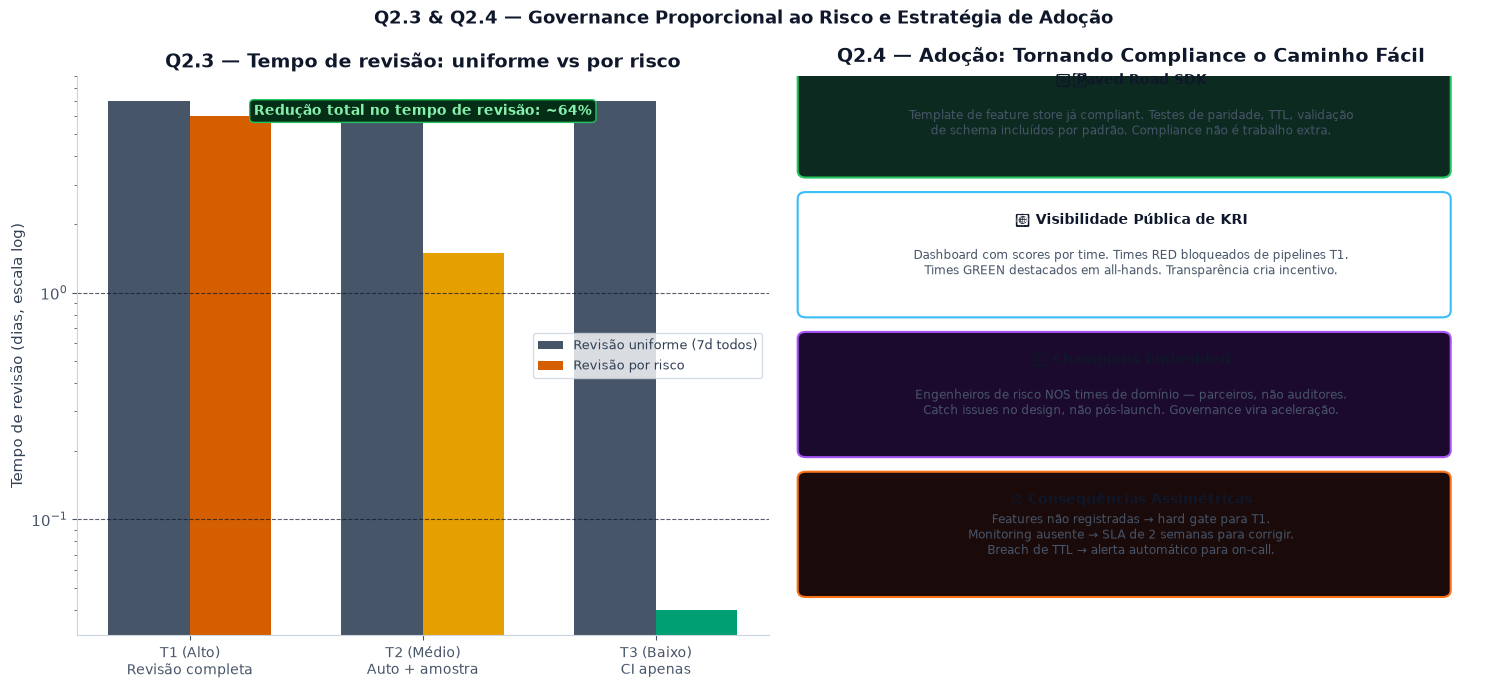

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Q2.3 & Q2.4 — Governance Proporcional ao Risco e Estratégia de Adoção',
             fontsize=13, color='#0f172a', fontweight='bold')

# Q2.3: Review time comparison
ax = axes[0]
tiers = ['T1 (Alto)\nRevisão completa', 'T2 (Médio)\nAuto + amostra', 'T3 (Baixo)\nCI apenas']
time_uniform = [7, 7, 7]
time_tiered  = [6, 1.5, 0.04]
x = np.arange(len(tiers)); w = 0.35
ax.bar(x-w/2, time_uniform, w, color='#475569', edgecolor='none', label='Revisão uniforme (7d todos)')
ax.bar(x+w/2, time_tiered,  w, color=[COL_HI, COL_MED, COL_LO], edgecolor='none', label='Revisão por risco')
ax.set_xticks(x); ax.set_xticklabels(tiers, fontsize=10)
ax.set_ylabel('Tempo de revisão (dias, escala log)'); ax.set_yscale('log')
ax.set_title('Q2.3 — Tempo de revisão: uniforme vs por risco')
ax.legend(fontsize=9); style_chart(ax)
savings = (1 - sum(time_tiered)/sum(time_uniform)) * 100
ax.text(0.5, 0.93, f'Redução total no tempo de revisão: ~{savings:.0f}%', transform=ax.transAxes,
        ha='center', fontsize=10, color='#86efac', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#052e16', edgecolor='#22c55e'))

# Q2.4: Adoption strategies
ax = axes[1]
ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')
ax.set_title('Q2.4 — Adoção: Tornando Compliance o Caminho Fácil', pad=10)

for (x,y,title,bg,border,desc) in [
    (5,9.5,'🛠️ Paved Road SDK','#0c2a1f','#22c55e',
     'Template de feature store já compliant. Testes de paridade, TTL, validação\nde schema incluídos por padrão. Compliance não é trabalho extra.'),
    (5,7.0,'📈 Visibilidade Pública de KRI','#ffffff','#38bdf8',
     'Dashboard com scores por time. Times RED bloqueados de pipelines T1.\nTimes GREEN destacados em all-hands. Transparência cria incentivo.'),
    (5,4.5,'🤝 Champions Embedded','#1c0a2e','#a855f7',
     'Engenheiros de risco NOS times de domínio — parceiros, não auditores.\nCatch issues no design, não pós-launch. Governance vira aceleração.'),
    (5,2.0,'⚖️ Consequências Assimétricas','#1a0a0a','#f97316',
     'Features não registradas → hard gate para T1.\nMonitoring ausente → SLA de 2 semanas para corrigir.\nBreach de TTL → alerta automático para on-call.'),
]:
    ax.add_patch(mpatches.FancyBboxPatch((0.3,y-1.2),9.2,2.0,boxstyle='round,pad=0.12',facecolor=bg,edgecolor=border,linewidth=1.5))
    ax.text(x,y+0.35,title,ha='center',fontsize=10,color='#0f172a',fontweight='bold')
    ax.text(x,y-0.55,desc,ha='center',fontsize=8.5,color='#475569')

fig.tight_layout()
plt.show()


---
## Resumo Final

In [22]:
conn_off.close()
conn_on.close()

print('=' * 70)
print('BUSINESS CASE — RESUMO EXECUTIVO')
print('=' * 70)
print()
print('Q1.1 RISCOS (observados rodando o sistema, não hipotéticos):')
print(f'  R1 CRÍTICO: {(df_merged["abs_delta"]>15).mean()*100:.0f}% dos clientes com >15% divergência offline/online')
print(f'  R2 ALTO   : FRESHNESS_TTL=6h definido, nunca enforçado no read path')
print(f'  R3 ALTO   : Dashboard mostra 100% uptime com features corrompidas')
print(f'  R4 MÉDIO  : CSV único sem validação, sem rollback no online store')
print()
print('Q1.2 TESTES: todos rodados contra stores live — resultados detalhados acima.')
print()
print('Q1.3 POSIÇÃO:')
print('  Mudança 1 (top-ups sem revisão) → PAUSE até R1+R2+R3 resolvidos')
print('  Mudança 2 (review mais leve) → PROSSEGUIR COM CONDIÇÕES (gates CI automatizados)')
print()
print('Q1.4 CONTROLES CHAVE:')
print('  C1: Enforce TTL em OnlineStore.get_features()  — fix de 1-2 dias')
print('  C2: Drift monitor contínuo (PSI + paridade)   — maior ROI por esforço')
print('  C3: Schema registry + shadow mode              — previne blast radius')
print()
print('Q2 GOVERNANCE FRAMEWORK:')
print('  Padronizar: contratos, SLA tiers, KRIs, gates de mudança, lineage metadata')
print('  Autonomia: tech stack, schedule, tamanho de janela, naming no namespace')
print('  KRIs: PSI drift, staleness %, parity fail %, features s/ owner, validação')
print('  Anti-gargalo: revisão por risco — T1=5-7d, T2=1-2d, T3=<1h automatizado')
print('  Adoção: paved-road SDK, visibilidade KRI, champions embedded, gates assimétricos')
print()
print('=' * 70)


BUSINESS CASE — RESUMO EXECUTIVO

Q1.1 RISCOS (observados rodando o sistema, não hipotéticos):
  R1 CRÍTICO: 70% dos clientes com >15% divergência offline/online
  R2 ALTO   : FRESHNESS_TTL=6h definido, nunca enforçado no read path
  R3 ALTO   : Dashboard mostra 100% uptime com features corrompidas
  R4 MÉDIO  : CSV único sem validação, sem rollback no online store

Q1.2 TESTES: todos rodados contra stores live — resultados detalhados acima.

Q1.3 POSIÇÃO:
  Mudança 1 (top-ups sem revisão) → PAUSE até R1+R2+R3 resolvidos
  Mudança 2 (review mais leve) → PROSSEGUIR COM CONDIÇÕES (gates CI automatizados)

Q1.4 CONTROLES CHAVE:
  C1: Enforce TTL em OnlineStore.get_features()  — fix de 1-2 dias
  C2: Drift monitor contínuo (PSI + paridade)   — maior ROI por esforço
  C3: Schema registry + shadow mode              — previne blast radius

Q2 GOVERNANCE FRAMEWORK:
  Padronizar: contratos, SLA tiers, KRIs, gates de mudança, lineage metadata
  Autonomia: tech stack, schedule, tamanho de janela,